# import

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')  # ou un autre style disponible
sns.set_theme(style="whitegrid")


In [53]:
df = pd.read_csv("data_tmp/bakery_sales_top12.csv")

In [54]:
df.head()

,Unnamed: 0,date,time,ticket_number,article,Quantity,unit_price
0,0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,8,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"
4,11,2021-01-02,09:25,150043.0,BAGUETTE,2.0,"0,90 €"


In [55]:
# all the columns in lower
df.columns = [col.lower() for col in df.columns]
# convert the columns to the right format
if 'unit_price' in df.columns:
    df['unit_price'] = (
        df['unit_price'].astype(str)
        .str.replace('€', '', regex=False)
        .str.replace('.', '', regex=False)    # remove thousands dots if any
        .str.replace(',', '.', regex=False)   # decimal comma -> dot
        .str.strip()
    )
    df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

df["date"] = pd.to_datetime(df["date"] + " " + df["time"], format="%Y-%m-%d %H:%M:%S").drop(columns=["time"])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df["is_weekend"] = df["day_of_week"].isin(['Saturday', 'Sunday']).astype(int)
df['revenue'] = df['quantity'] * df['unit_price']


In [56]:
df.drop(columns=['unnamed: 0'], inplace=True)
# save df
df.to_csv("data_tmp/bakery_sales_top12_cleaned.csv", index=False)

In [57]:
print(df[['quantity', 'unit_price', 'revenue']].describe())

            quantity     unit_price        revenue
count  143702.000000  143702.000000  143702.000000
mean        1.751367       1.273093       2.190788
std         1.280744       0.322790       1.601627
min         1.000000       0.900000       0.900000
25%         1.000000       1.150000       1.200000
50%         1.000000       1.200000       1.700000
75%         2.000000       1.300000       2.500000
max        55.000000       2.600000      66.000000


In [58]:
df

,date,time,ticket_number,article,quantity,unit_price,year,month,day_of_week,hour,is_weekend,revenue
0,2021-01-02 08:38:00,08:38,150040.0,BAGUETTE,1.0,0.9,2021,1,Saturday,8,1,0.9
1,2021-01-02 08:38:00,08:38,150040.0,PAIN AU CHOCOLAT,3.0,1.2,2021,1,Saturday,8,1,3.6
2,2021-01-02 09:14:00,09:14,150041.0,PAIN AU CHOCOLAT,2.0,1.2,2021,1,Saturday,9,1,2.4
3,2021-01-02 09:25:00,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,1.2,2021,1,Saturday,9,1,6.0
4,2021-01-02 09:25:00,09:25,150043.0,BAGUETTE,2.0,0.9,2021,1,Saturday,9,1,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...
143697,2022-09-30 18:39:00,18:39,288910.0,TRADITIONAL BAGUETTE,1.0,1.3,2022,9,Friday,18,0,1.3
143698,2022-09-30 18:52:00,18:52,288911.0,CAMPAGNE,2.0,2.0,2022,9,Friday,18,0,4.0
143699,2022-09-30 18:52:00,18:52,288911.0,TRADITIONAL BAGUETTE,5.0,1.3,2022,9,Friday,18,0,6.5
143700,2022-09-30 18:55:00,18:55,288912.0,TRADITIONAL BAGUETTE,1.0,1.3,2022,9,Friday,18,0,1.3


## Popularity and frequency

In [59]:
narticle = df['article'].nunique()
print(f"There are {narticle} different articles in the dfbase. ")

There are 12 different articles in the dfbase. 


In [60]:
# Total quantity sold per article (best measure of "more bought")
qty_by_article = (
    df.groupby('article', as_index=False)['quantity']
      .sum()
      .sort_values('quantity', ascending=False)
      .rename(columns={'quantity': 'total_quantity'})
)
total_qty = qty_by_article['total_quantity'].sum()
qty_by_article['pct'] = (qty_by_article['total_quantity'] / total_qty) * 100
print(qty_by_article)

# How often each article appears (number of rows) for "appears frequently", regardless of amount
linecount_by_article = (
    df['article'].value_counts().rename_axis('article').reset_index(name='line_count')
)
# for the %
total_lines = linecount_by_article['line_count'].sum()
linecount_by_article['pct'] = (linecount_by_article['line_count'] / total_lines) * 100
print(linecount_by_article)

# % of total sales
df['revenue'] = df['quantity'] * df['unit_price']
rev_by_article = (
    df.groupby('article', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)
total_rev = rev_by_article['revenue'].sum()
rev_by_article['pct'] = (rev_by_article['revenue'] / total_rev) * 100
print(rev_by_article)

                 article  total_quantity        pct
11  TRADITIONAL BAGUETTE        117456.0  46.669713
6              CROISSANT         29677.0  11.791795
8       PAIN AU CHOCOLAT         25244.0  10.030396
1                BANETTE         22731.0   9.031886
0               BAGUETTE         22059.0   8.764875
4        CEREAL BAGUETTE          7426.0   2.950631
9          SPECIAL BREAD          5458.0   2.168670
10            TARTELETTE          5012.0   1.991457
2             BOULE 400G          4822.0   1.915963
3               CAMPAGNE          4356.0   1.730804
5                 COOKIE          3779.0   1.501540
7                 ECLAIR          3655.0   1.452270
                 article  line_count        pct
0   TRADITIONAL BAGUETTE       66996  46.621481
1               BAGUETTE       15161  10.550305
2                BANETTE       14909  10.374943
3              CROISSANT       11397   7.930996
4       PAIN AU CHOCOLAT       10476   7.290086
5          SPECIAL BREAD        5135

In [61]:
print("In general, the most purchased items are also the most frequently bought.")
print("Exceptions: ")
for i in linecount_by_article[:15]["article"].tolist():
    if i not in qty_by_article[:15]["article"].tolist():
        total_qty = qty_by_article.loc[qty_by_article['article'] == i, 'total_quantity'].values[0]
        line_cnt = linecount_by_article.loc[linecount_by_article['article'] == i, 'line_count'].values[0]
        print(f"{i} is bought more frequently but in smaller quantity, {total_qty} times and in {line_cnt} occasions")
for j in qty_by_article[:15]["article"].tolist():
    if j not in linecount_by_article[:15]["article"].tolist():
        total_qty = qty_by_article.loc[qty_by_article['article'] == j, 'total_quantity'].values[0]
        line_cnt = linecount_by_article.loc[linecount_by_article['article'] == j, 'line_count'].values[0]
        print(f"{j} is bought less frequently but in bigger quantity {total_qty} times and in {line_cnt} occasions")

In general, the most purchased items are also the most frequently bought.
Exceptions: 


In [62]:
TOP_N = 12
popularity = qty_by_article.merge(linecount_by_article, on='article', how='left')

In [63]:
def plot_top_n_articles_quantity(qty_df, SAVE_PLOTS=False, n=12, title_prefix="Top"):
    top = qty_df.head(n).copy()
    fig, ax = plt.subplots(figsize=(8, max(6, n * 0.3)))
    
    bars = ax.barh(top['article'], top['total_quantity'], color='darkorange')
    ax.invert_yaxis()
    ax.set_xlabel("Total quantity sold")
    ax.set_ylabel("Article")
    ax.set_title(f"{title_prefix} {n} articles — total quantity sold (%)")

    # Add percentage labels to the end of each bar
    for bar, pct in zip(bars, top['pct']):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f' {pct:.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(f"top_{n}_articles_quantity_pct.png", dpi=150)
    plt.show()

def plot_top_n_by_linecount(pop_df, SAVE_PLOTS=False, n=12):
    top = pop_df.sort_values('line_count', ascending=False).head(n)
    fig, ax = plt.subplots(figsize=(8, max(6, n * 0.3)))
    
    bars = ax.barh(top['article'], top['line_count'], color='salmon')
    ax.invert_yaxis()
    ax.set_xlabel("Number of lines (appearances)")
    ax.set_ylabel("Article")
    ax.set_title(f"Top {n} articles — frequency of appearance (%)")

    for bar, pct in zip(bars, top['pct']):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f' {pct:.1f}%', va='center', fontweight='bold')


def plot_top_n_by_revenue(rev_df, SAVE_PLOTS=False, n=12):
    top = rev_df.head(n)
    fig, ax = plt.subplots(figsize=(8, max(6, n * 0.3)))
    
    bars = ax.barh(top['article'], top['revenue'], color='darkred')
    ax.invert_yaxis()
    ax.set_xlabel("Total Revenue (€)")
    ax.set_title(f"Top {n} articles — Contribution to Revenue (%)")

    for bar, pct in zip(bars, top['pct']):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f' {pct:.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(f"top_{n}_articles_revenue_pct.png", dpi=150)
    plt.show()

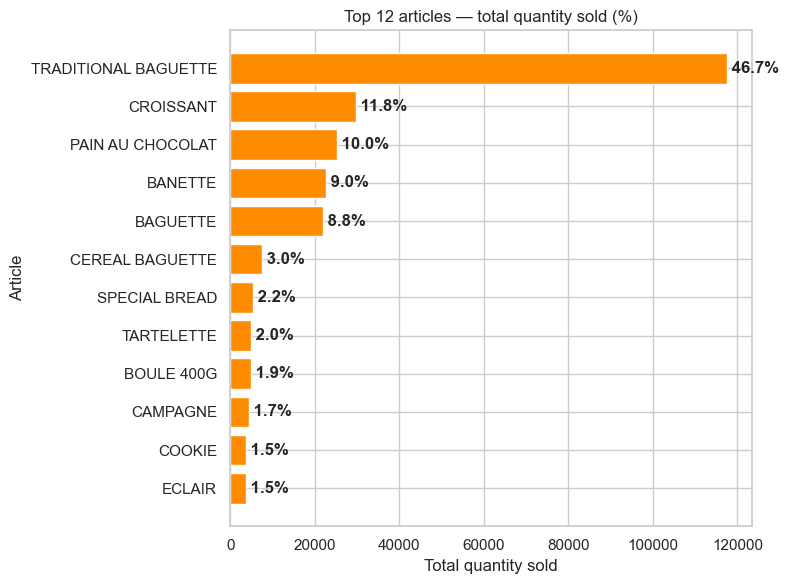

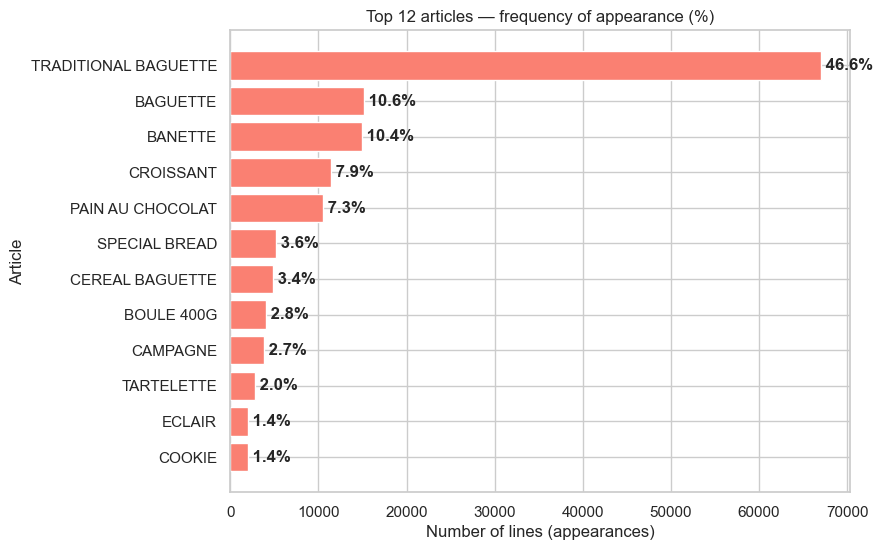

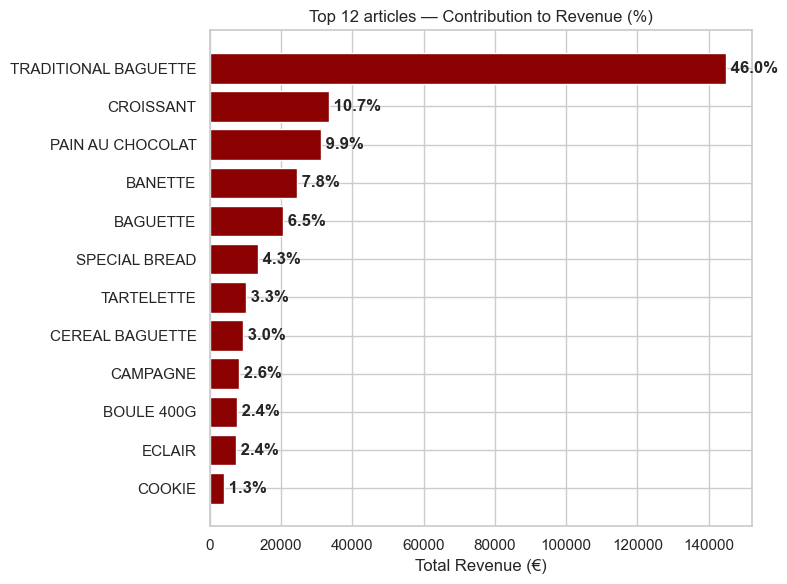

In [64]:
plot_top_n_articles_quantity(qty_by_article, n=TOP_N)
plot_top_n_by_linecount(linecount_by_article, n=TOP_N)
plot_top_n_by_revenue(rev_by_article, n=TOP_N)

### Conclusions:

- Quantity
    - 46.7% of the articles sold are TRADITIONAL BAGUETTE
    - CROISSANT and PAIN AU CHOCOLAT are your next biggest items, contributing 11% and 10% to total revenue respectively.
- Proportion of revenue
    - TRADITIONAL BAGUETTE represents the 46% of the total sales (in €) followed by CROISSANT and PAIN AU CHOCOLAT wich, together, represent 20% of the revenue.

-> As we took the 12 more frequent articles, we are not surprised that  the most sold are the ones that make more money.

## Price variation in time (when max price =! min price?)

In [65]:
price_min_max = df.groupby('article').agg({'unit_price': ['min', 'max']})
price_min_max.columns = price_min_max.columns.droplevel(0)
price_min_max = price_min_max[price_min_max["min"]!=0]

# quels articles min!=max
evolution = price_min_max[price_min_max['min']!=price_min_max['max']]
print(f"There's {len(evolution)} articles which price has evolve in time")
evolution["diff"] = -evolution['min']+evolution["max"]
print("The articles with the bigger difference: ")
e = evolution.sort_values(by="diff", ascending=False).head()
e.iloc[:7]

There's 12 articles which price has evolve in time
The articles with the bigger difference: 


,min,max,diff
article,,,
ECLAIR,2.0,2.2,0.2
SPECIAL BREAD,2.4,2.6,0.2
TARTELETTE,2.0,2.2,0.2
BOULE 400G,1.5,1.7,0.2
CAMPAGNE,1.8,2.0,0.2


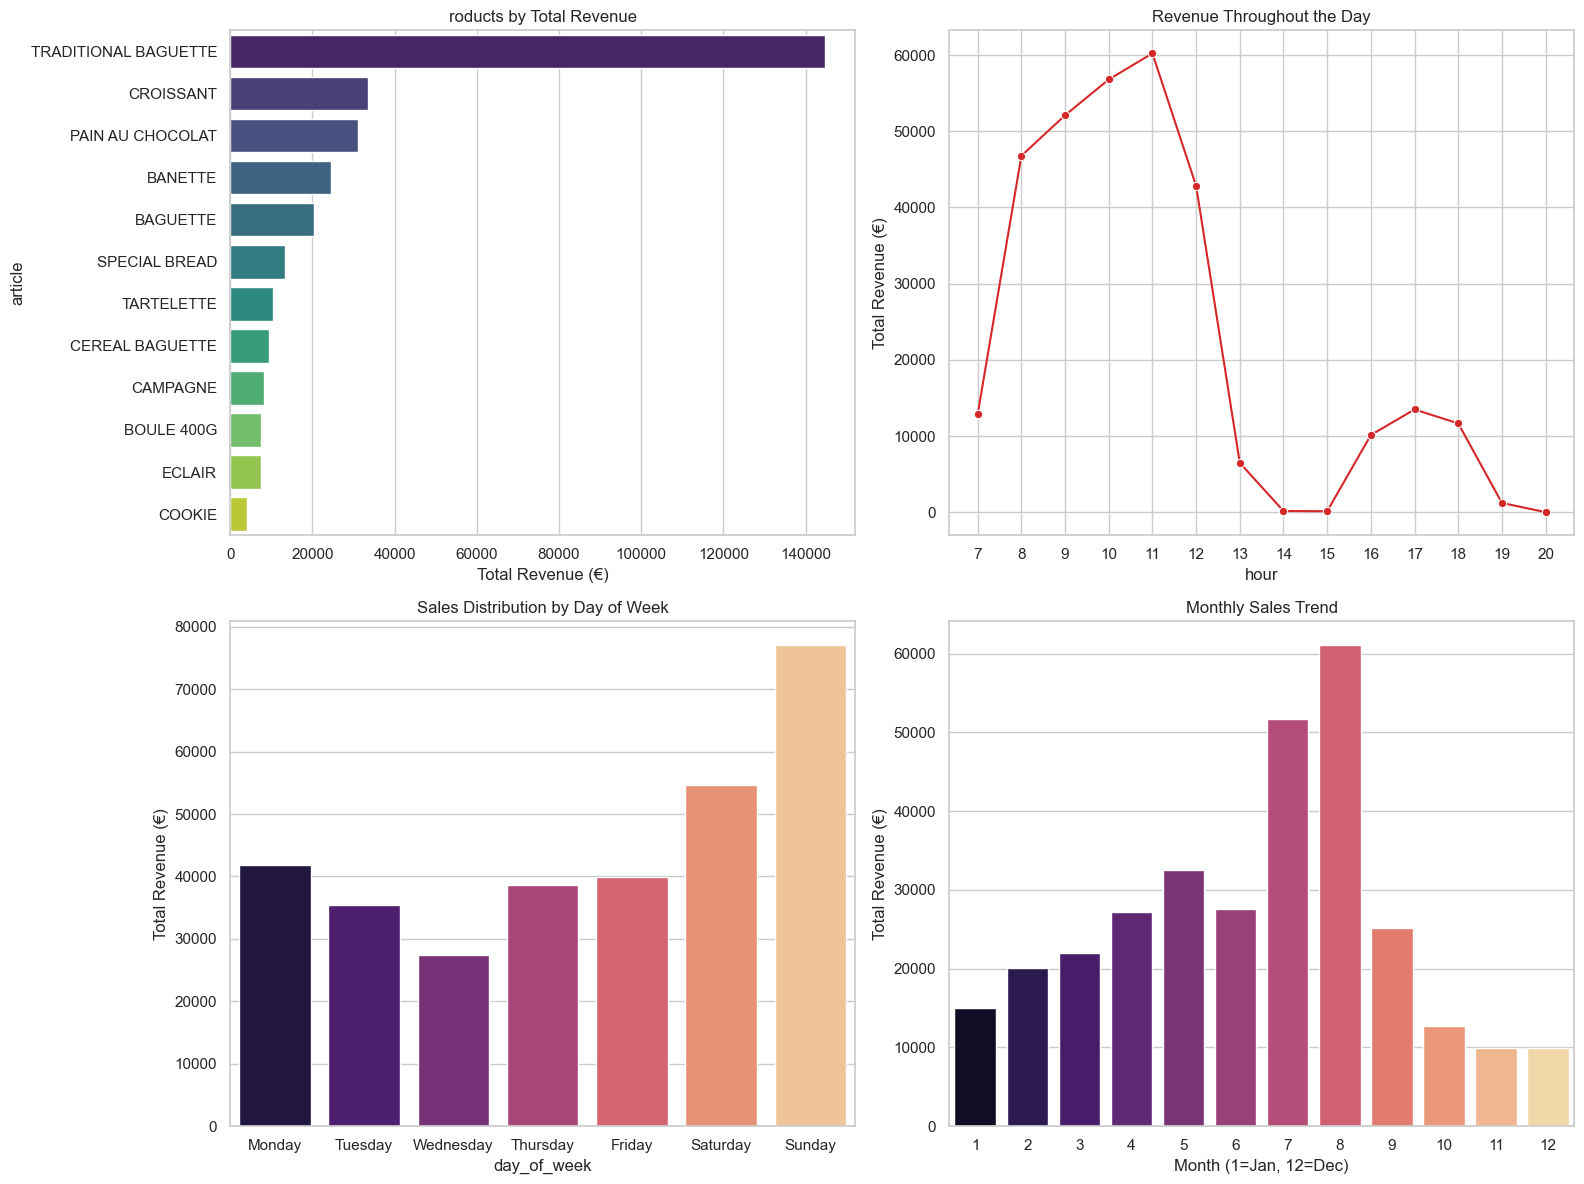


Key numbers:
Total Revenue: €314,820.55
Top Selling Product: TRADITIONAL BAGUETTE
Busiest Hour: 11:00
Strongest Sales Day: Sunday


In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Articles by Revenue
top_revenue = df.groupby('article')['revenue'].sum().sort_values(ascending=False).head(12)
sns.barplot(x=top_revenue.values, y=top_revenue.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('roducts by Total Revenue')
axes[0, 0].set_xlabel('Total Revenue (€)')

# Hourly Sales Pattern
hourly_sales = df.groupby('hour')['revenue'].sum()
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', ax=axes[0, 1], color='tab:red')
axes[0, 1].set_title('Revenue Throughout the Day')
axes[0, 1].set_xticks(range(int(df['hour'].min()), int(df['hour'].max()) + 1))
axes[0, 1].set_ylabel('Total Revenue (€)')

# Weekly Sales Pattern
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales = df.groupby('day_of_week')['revenue'].sum().reindex(days_order)
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Sales Distribution by Day of Week')
axes[1, 0].set_ylabel('Total Revenue (€)')

# Monthly Sales (Seasonality)
monthly_sales = df.groupby('month')['revenue'].sum()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Monthly Sales Trend')
axes[1, 1].set_xlabel('Month (1=Jan, 12=Dec)')
axes[1, 1].set_ylabel('Total Revenue (€)')

plt.tight_layout()
plt.show()

# Correlation check
print("\nKey numbers:")
print(f"Total Revenue: €{df['revenue'].sum():,.2f}")
print(f"Top Selling Product: {top_revenue.index[0]}")
print(f"Busiest Hour: {hourly_sales.idxmax()}:00")
print(f"Strongest Sales Day: {weekly_sales.idxmax()}")


- **Pricing**: The average unit price is approximately €1.27, indicating a high-volume, low-ticket retail model typical of neighborhood bakeries.
- **Temporal Patterns** (When people buy)
    - The Morning Rush: Sales begin to climb early in the morning, peaking sharply at 11:00 AM. This suggests a late-morning customer base. There is a secondary, smaller peak in the late afternoon.
    - Weekend: Sunday is the busiest day of the week for this bakery. Sunday will require the highest headcount
    - Summer Peak: There is a massive spike in sales during July and August. Revenue in August ($61,033$€) is nearly 6x higher than in November ($9,935$€). This strongly suggests the bakery is located in a tourist-heavy area or a seasonal vacation spot.